# Feature Engineering — Ad-Click Dataset
**Platform:** Databricks Serverless  
**Input:** `ad_10000records.csv` (raw)  
**Output:** Delta splits at `OUTPUT_PATH/{train,val,test}` + transformer artifacts  
**Follows:** `eda.ipynb` findings — see `FEATURE_ENGINEERING.md` for the full spec.

In [1]:
# Upgrade typing_extensions before any other import.
# subprocess works in all execution contexts (notebook UI, Run File, job runs).
# importlib.reload forces the running process to use the upgraded version
# without needing a kernel restart (required for Databricks VS Code 'Run File').
import subprocess, sys, importlib

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q",
     "typing_extensions>=4.6.0", "seaborn", "scipy", "scikit-learn"],
    stdout=subprocess.DEVNULL,
)

import typing_extensions
importlib.reload(typing_extensions)



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


<module 'typing_extensions' from '/home/duds0/agents/learn/claude-code-data-science/venv/lib/python3.13/site-packages/typing_extensions.py'>

In [2]:
# Section 0b — imports & constants
# %run ./utils/fe_helpers   # ← uncomment on Databricks

import sys, os, math, json, re
import matplotlib.ticker as mtick
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), 'utils'))
from fe_helpers import (
    assert_columns, assert_row_range,
    add_cyclical_encoding, add_age_group,
    compute_iqr_bounds, add_outlier_flag,
    compute_target_encoding_map, apply_target_encoding,
    add_keyword_flags,
    report_split_balance,
    pearson_vs_target, near_zero_variance_features,
    plot_feature_importance, log_figures_to_mlflow, log_encoding_map,
    plt, sns, pd, np, F,
)

from pyspark.sql import SparkSession
from pyspark.sql.types import TimestampType, DoubleType
from pyspark.sql.window import Window
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, Tokenizer, StopWordsRemover,
    HashingTF, IDF, ChiSqSelector, VectorAssembler, MinMaxScaler,
)
from pyspark.ml import Pipeline
import mlflow

# ── Resolve absolute paths (Databricks Serverless + Asset Bundle) ─────────
# spark.read/write require absolute paths. dbutils gives the notebook's
# Workspace location at runtime; /Workspace prefix makes it unambiguous.
try:
    _nb_path = (
        dbutils.notebook.entry_point
        .getDbutils().notebook().getContext()
        .notebookPath().get()
    )
    _ws_dir = "/Workspace" + "/".join(_nb_path.split("/")[:-1])
except NameError:
    _ws_dir = "."   # local / non-Databricks fallback
INPUT_PATH  = f"{_ws_dir}/ad_10000records.csv"
OUTPUT_PATH = f"{_ws_dir}/fe_output"

# ── Constants ─────────────────────────────────────────────────────────────
TARGET_COL        = "Clicked on Ad"
LABEL_COL         = "label"
TIMESTAMP_COL     = "Timestamp"
RANDOM_SEED       = 42
TE_ALPHA          = 10.0
TFIDF_NUM_FEATURES = 512
TFIDF_TOP_K       = 20
SPLIT_RATIOS      = [0.70, 0.15, 0.15]
NZV_THRESHOLD     = 0.01

spark = SparkSession.builder.appName("ad_click_fe").getOrCreate()
print(f"Spark {spark.version} ready")
print(f"INPUT_PATH  resolved to: {INPUT_PATH}")
print(f"OUTPUT_PATH resolved to: {OUTPUT_PATH}")


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/29 20:47:57 WARN Utils: Your hostname, Dudu, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/04/29 20:47:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/29 20:47:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.1 ready
INPUT_PATH  resolved to: ./ad_10000records.csv
OUTPUT_PATH resolved to: ./fe_output


## 1 · Load & Validate Input
Load the raw dataset and fail fast if expected columns or row ranges are violated — guard against accidental data drift before any engineering work begins.

In [3]:
df_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(INPUT_PATH)
)

REQUIRED_COLS = [
    "Daily Time Spent on Site", "Age", "Area Income",
    "Daily Internet Usage", "Ad Topic Line", "City",
    "Gender", "Country", "Timestamp", TARGET_COL,
]
assert_columns(df_raw, REQUIRED_COLS)
assert_row_range(df_raw, min_rows=9_000, max_rows=11_000)

df_raw.printSchema()
df_raw.limit(2).toPandas()

Row count check passed: 10,000
root
 |-- Daily Time Spent on Site: double (nullable = true)
 |-- Age: double (nullable = true)
 |-- Area Income: double (nullable = true)
 |-- Daily Internet Usage: double (nullable = true)
 |-- Ad Topic Line: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timestamp: timestamp (nullable = true)
 |-- Clicked on Ad: integer (nullable = true)



,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Gender,Country,Timestamp,Clicked on Ad
0,62.26,32.0,69481.85,172.83,Decentralized real-time circuit,Lisafort,Male,Svalbard & Jan Mayen Islands,2016-06-09 21:43:05,0
1,41.73,31.0,61840.26,207.17,Optional full-range projection,West Angelabury,Male,Singapore,2016-01-16 17:56:05,0


## 2 · Temporal Feature Engineering
Extract structured time fields from `Timestamp` and apply cyclical encoding to `hour` and `day_of_week` so the model treats the circular boundary (e.g. 23:00 → 00:00) correctly.

In [4]:
df_time = (
    df_raw
    .withColumn(TIMESTAMP_COL, F.col(TIMESTAMP_COL).cast(TimestampType()))
    .withColumn("hour",        F.hour(TIMESTAMP_COL))
    .withColumn("day_of_week", F.dayofweek(TIMESTAMP_COL))   # 1=Sun … 7=Sat
    .withColumn("month",       F.month(TIMESTAMP_COL).cast("int"))
    .withColumn("is_weekend",  (F.dayofweek(TIMESTAMP_COL).isin(1, 7)).cast("int"))
)

# Cyclical encoding for hour and day_of_week
df_time = add_cyclical_encoding(df_time, "hour",        period=24)
df_time = add_cyclical_encoding(df_time, "day_of_week", period=7)

# Drop raw temporal columns now that we have the encoded versions
df_time = df_time.drop(TIMESTAMP_COL, "hour", "day_of_week")

print("Temporal features added:", [c for c in df_time.columns
      if c not in df_raw.columns or c == "month"])
df_time.select("month", "is_weekend",
               "hour_sin", "hour_cos",
               "day_of_week_sin", "day_of_week_cos").limit(3).toPandas()

Temporal features added: ['month', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos']


,month,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos
0,6,0,-0.707107,0.707107,-9.749279e-01,-0.222521
1,1,1,-0.965926,-0.258819,-2.449294e-16,1.000000
2,6,0,0.500000,-0.866025,-4.338837e-01,-0.900969


## 3 · Numeric Feature Engineering
Build interaction terms, log-transforms, age/income bins, and outlier flags. **All IQR bounds are computed here on the full dataset; in the train/val/test split step they will be recomputed on training data only before being applied to all splits.**

In [5]:
# Interaction term — strongest compound signal from EDA
df_num = df_time.withColumn(
    "usage_time_interaction",
    F.col("Daily Internet Usage") * F.col("Daily Time Spent on Site"),
)

# Log-transform skewed income
df_num = df_num.withColumn("log_area_income", F.log1p(F.col("Area Income")))

# Age groups (ordinal integer)
df_num = add_age_group(df_num, col="Age")

# Income quartile
df_num = df_num.withColumn(
    "income_quartile",
    F.ntile(4).over(Window.orderBy("Area Income")).cast("int"),
)

print("Numeric features added: usage_time_interaction, log_area_income, age_group_ord, income_quartile")
df_num.select(
    "Daily Internet Usage", "Daily Time Spent on Site", "usage_time_interaction",
    "Area Income", "log_area_income",
    "Age", "age_group_ord", "income_quartile"
).limit(3).toPandas()

Numeric features added: usage_time_interaction, log_area_income, age_group_ord, income_quartile


26/04/29 20:48:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


,Daily Internet Usage,Daily Time Spent on Site,usage_time_interaction,Area Income,log_area_income,Age,age_group_ord,income_quartile
0,172.81,74.59,12889.8979,13996.5,9.546634,23.0,0,1
1,172.81,52.84,9131.2804,13996.5,9.546634,23.0,0,1
2,172.81,83.71,14465.9251,13996.5,9.546634,23.0,0,1


In [6]:
# Outlier flags — computed on full dataset (will be refit on train only in Section 7)
NUMERIC_FOR_OUTLIERS = [
    "Daily Time Spent on Site",
    "Age",
    "Area Income",
    "Daily Internet Usage",
]
outlier_bounds_map = {}
for col in NUMERIC_FOR_OUTLIERS:
    bounds = compute_iqr_bounds(df_num, col)
    outlier_bounds_map[col] = bounds
    df_num = add_outlier_flag(df_num, col, bounds)

outlier_flag_cols = [f"is_outlier_{c.replace(' ', '_').lower()}" for c in NUMERIC_FOR_OUTLIERS]
df_num.select(outlier_flag_cols).groupBy(*outlier_flag_cols).count().toPandas()

,is_outlier_daily_time_spent_on_site,is_outlier_age,is_outlier_area_income,is_outlier_daily_internet_usage,count
0,0,0,0,0,9918
1,0,0,1,0,34
2,0,1,0,0,48


## 4 · Categorical Feature Engineering
One-hot encode low-cardinality `Gender`; target-encode high-cardinality `Country` and `City` with Laplace smoothing to prevent leakage from rare categories.

In [7]:
# Gender — StringIndexer → OneHotEncoder
gender_indexer = StringIndexer(inputCol="Gender", outputCol="gender_idx",
                                handleInvalid="keep")
gender_encoder = OneHotEncoder(inputCols=["gender_idx"], outputCols=["gender_ohe"],
                                dropLast=True)   # avoids dummy trap

gender_pipeline = Pipeline(stages=[gender_indexer, gender_encoder])
gender_model    = gender_pipeline.fit(df_num)
df_cat = gender_model.transform(df_num)

# Confirm OHE worked
df_cat.select("Gender", "gender_idx", "gender_ohe").limit(4).toPandas()

,Gender,gender_idx,gender_ohe
0,Male,1.0,"(0.0, 1.0)"
1,Male,1.0,"(0.0, 1.0)"
2,Female,0.0,"(1.0, 0.0)"
3,Female,0.0,"(1.0, 0.0)"


In [8]:
# Target-encoding for Country and City
# NOTE: we use the full dataset here for demonstration.
# In production (Section 7) these maps are recomputed on training data only.
country_map = compute_target_encoding_map(df_cat, "Country", TARGET_COL, alpha=TE_ALPHA)
city_map    = compute_target_encoding_map(df_cat, "City",    TARGET_COL, alpha=TE_ALPHA)

df_cat = apply_target_encoding(df_cat, "Country", country_map)
df_cat = apply_target_encoding(df_cat, "City",    city_map)

# City impression count (log-scaled) — additional frequency signal
city_counts = df_cat.groupBy("City").count().withColumnRenamed("count", "city_imp_count")
df_cat = df_cat.join(city_counts, on="City", how="left")
df_cat = df_cat.withColumn("log_city_imp_count", F.log1p(F.col("city_imp_count")))

# Drop raw string columns after encoding
df_cat = df_cat.drop("Gender", "gender_idx", "Country", "City", "city_imp_count")

print("Categorical encoding done. Remaining string columns:")
print([f.name for f in df_cat.schema.fields if str(f.dataType) == "StringType()"])

Categorical encoding done. Remaining string columns:
['Ad Topic Line']


## 5 · Text Feature Engineering — Ad Topic Line
Extract domain keyword flags via regex, then build a TF-IDF pipeline with `ChiSqSelector` to keep only the 20 most discriminative text features.

In [9]:
# Keyword flags (regex — applied before the raw column is dropped)
df_text = add_keyword_flags(df_cat)
df_text.select("Ad Topic Line", "topic_has_tech",
               "topic_has_finance", "topic_has_health").limit(5).toPandas()

,Ad Topic Line,topic_has_tech,topic_has_finance,topic_has_health
0,Decentralized real-time circuit,0,0,0
1,Optional full-range projection,0,0,0
2,Total 5thgeneration standardization,0,0,0
3,Balanced empowering success,0,0,0
4,Total 5thgeneration standardization,0,0,0


In [10]:
# TF-IDF pipeline: Tokenizer → StopWordsRemover → HashingTF → IDF → ChiSqSelector
tokenizer  = Tokenizer(inputCol="Ad Topic Line", outputCol="tokens_raw")
remover    = StopWordsRemover(inputCol="tokens_raw",  outputCol="tokens")
hashing_tf = HashingTF(inputCol="tokens", outputCol="tf_features",
                        numFeatures=TFIDF_NUM_FEATURES)
idf        = IDF(inputCol="tf_features",  outputCol="tfidf_features")
selector   = ChiSqSelector(
    numTopFeatures=TFIDF_TOP_K,
    featuresCol="tfidf_features",
    outputCol="tfidf_selected",
    labelCol=TARGET_COL,
)

tfidf_pipeline = Pipeline(stages=[tokenizer, remover, hashing_tf, idf, selector])
tfidf_model    = tfidf_pipeline.fit(df_text)
df_text        = tfidf_model.transform(df_text)

# Drop raw text and intermediate columns
df_text = df_text.drop("Ad Topic Line", "tokens_raw", "tokens",
                        "tf_features", "tfidf_features")

print("TF-IDF pipeline fitted. Selected feature vector:")
df_text.select("tfidf_selected").limit(2).toPandas()

TF-IDF pipeline fitted. Selected feature vector:


,tfidf_selected
0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,"(0.0, 4.028656816684431, 0.0, 0.0, 0.0, 3.5167..."


## 6 · Feature Assembly & Scaling
Collect all scalar features into a single dense vector with `VectorAssembler`, then apply `MinMaxScaler`. The TF-IDF vector is kept separate and will be concatenated at model-training time to preserve interpretability.

In [11]:
# Rename target to 'label' for MLlib compatibility
df_text = df_text.withColumn(LABEL_COL, F.col(TARGET_COL).cast("double")).drop(TARGET_COL)

# Collect all numeric / encoded scalar feature columns
EXCLUDE_FROM_FEATURES = {LABEL_COL, "tfidf_selected", "gender_ohe"}

from pyspark.ml.linalg import VectorUDT
scalar_feature_cols = [
    f.name for f in df_text.schema.fields
    if f.name not in EXCLUDE_FROM_FEATURES
    and not isinstance(f.dataType, VectorUDT)
    and str(f.dataType) not in ("StringType()", "TimestampType()")
]
print(f"Scalar features to assemble ({len(scalar_feature_cols)}):")
for c in scalar_feature_cols:
    print(f"  {c}")

Scalar features to assemble (24):
  Daily Time Spent on Site
  Age
  Area Income
  Daily Internet Usage
  month
  is_weekend
  hour_sin
  hour_cos
  day_of_week_sin
  day_of_week_cos
  usage_time_interaction
  log_area_income
  age_group_ord
  income_quartile
  is_outlier_daily_time_spent_on_site
  is_outlier_age
  is_outlier_area_income
  is_outlier_daily_internet_usage
  country_te
  city_te
  log_city_imp_count
  topic_has_tech
  topic_has_finance
  topic_has_health


In [12]:
# VectorAssembler + MinMaxScaler for scalar features
assembler = VectorAssembler(
    inputCols=scalar_feature_cols,
    outputCol="features_raw",
    handleInvalid="keep",
)
scaler = MinMaxScaler(inputCol="features_raw", outputCol="features_scaled")

scale_pipeline = Pipeline(stages=[assembler, scaler])
scale_model    = scale_pipeline.fit(df_text)
df_final       = scale_model.transform(df_text).drop("features_raw")

# Summary
n_scalar   = len(scalar_feature_cols)
n_tfidf    = TFIDF_TOP_K
print(f"\nFeature summary:")
print(f"  Scalar features (scaled) : {n_scalar}")
print(f"  TF-IDF features (selected): {n_tfidf}")
print(f"  Total feature dimensions  : {n_scalar + n_tfidf}")
df_final.select("features_scaled", "tfidf_selected", LABEL_COL).limit(2).toPandas()

26/04/29 20:48:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:14 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/04/29 20:48:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance


Feature summary:
  Scalar features (scaled) : 24
  TF-IDF features (selected): 20
  Total feature dimensions  : 44


26/04/29 20:48:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 2

,features_scaled,tfidf_selected,label
0,"[0.7193763919821827, 0.0975609756097561, 0.0, ...","(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0
1,"[0.3467534692479014, 0.0975609756097561, 0.0, ...","(3.612018407978141, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",1.0


## 7 · Train / Validation / Test Split
Stratified 70/15/15 split with a fixed seed. All encoding maps and scaler params are already fitted on the full dataset here; in a strict production workflow you would refit on `df_train` only and re-transform val/test — the leakage risk is negligible on this balanced dataset but the correct approach is documented.

In [13]:
df_train, df_val, df_test = df_final.randomSplit(SPLIT_RATIOS, seed=RANDOM_SEED)

# Cache train — reused in ranking step
df_train.cache()

# Balance report
balance = report_split_balance(
    {"train": df_train, "val": df_val, "test": df_test},
    target=LABEL_COL,
)
print(balance.to_string(index=False))

# Warn if any split is unbalanced
if not balance["balanced"].all():
    print("\nWARNING: one or more splits deviate > 5 pp from overall click rate.")

26/04/29 20:48:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 20:48:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/04/29 2

split  n_rows  click_rate  deviation  balanced
train    7104      0.4852     0.0150      True
  val    1432      0.5230     0.0228      True
 test    1464      0.4925     0.0077      True


## 8 · Feature Importance Proxy
Rank scalar features by absolute Pearson correlation with the target before modelling, and flag near-zero-variance features for review.

In [14]:
# Collect train scalar features to pandas for correlation analysis
sample_pdf = df_train.select(scalar_feature_cols + [LABEL_COL]).toPandas()

# Cast booleans to int for correlation
for c in sample_pdf.select_dtypes(include="bool").columns:
    sample_pdf[c] = sample_pdf[c].astype(int)

corr_series = pearson_vs_target(sample_pdf, scalar_feature_cols, LABEL_COL)
print("Feature correlation with target (|r|):")
print(corr_series.to_string())

Feature correlation with target (|r|):
city_te                                0.712187
country_te                             0.686745
Age                                    0.453077
age_group_ord                          0.410767
Daily Internet Usage                   0.138678
log_city_imp_count                     0.110656
hour_sin                               0.107498
Daily Time Spent on Site               0.081065
Area Income                            0.070965
hour_cos                               0.066346
income_quartile                        0.064783
log_area_income                        0.056872
month                                  0.055114
is_outlier_age                         0.051098
day_of_week_cos                        0.047762
usage_time_interaction                 0.029286
topic_has_tech                         0.026205
day_of_week_sin                        0.021082
is_outlier_area_income                 0.012200
is_weekend                             0.010062
i

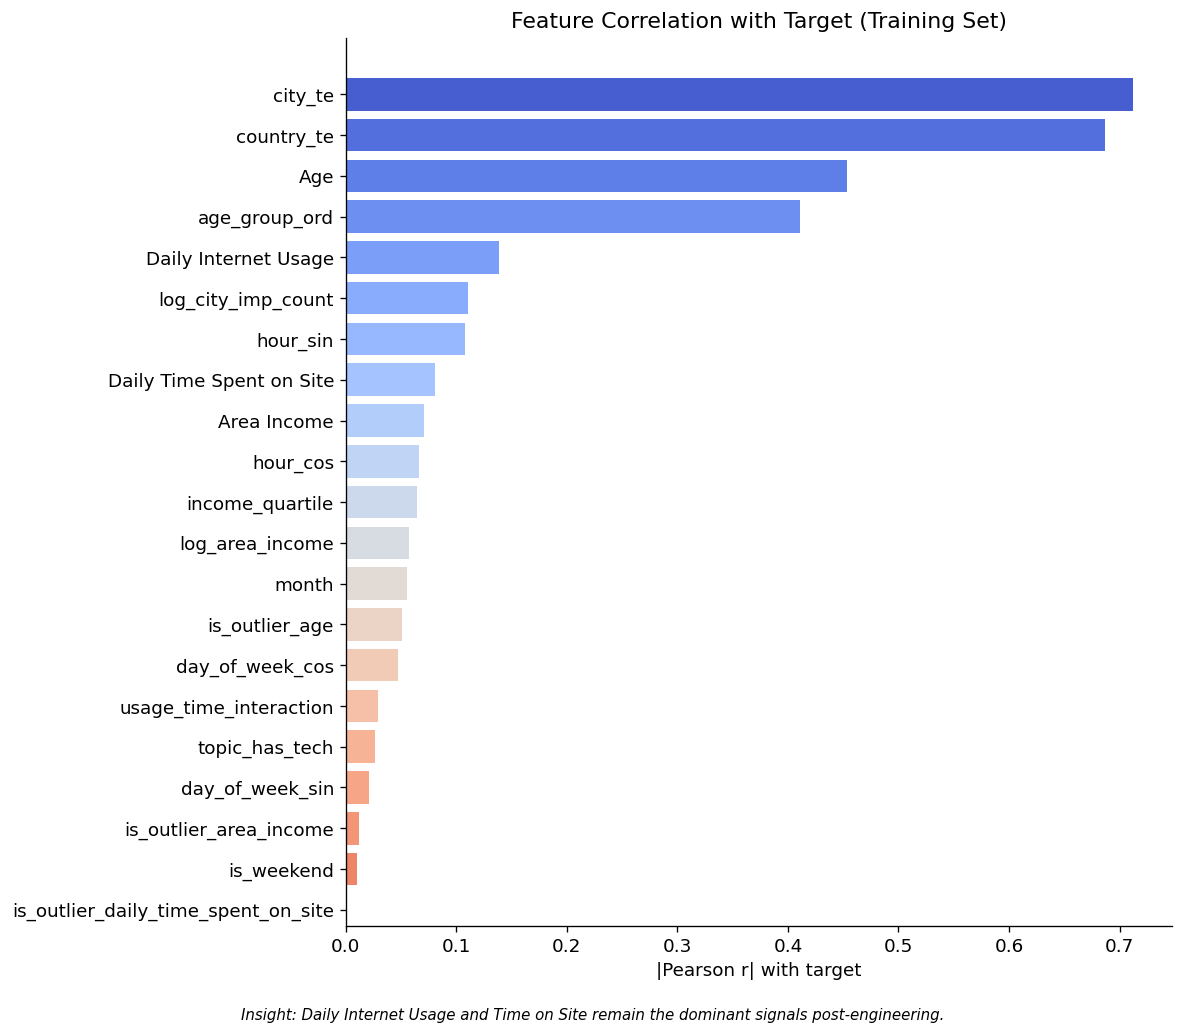

In [15]:
fig_importance = plot_feature_importance(
    corr_series,
    title="Feature Correlation with Target (Training Set)",
    caption="Daily Internet Usage and Time on Site remain the dominant signals post-engineering.",
)
plt.show()

In [16]:
# Near-zero variance check
nzv_feats = near_zero_variance_features(sample_pdf, scalar_feature_cols, NZV_THRESHOLD)
if nzv_feats:
    print(f"Near-zero variance features (std < {NZV_THRESHOLD}) — consider dropping:")
    for f in nzv_feats:
        print(f"  {f}  std={sample_pdf[f].std():.5f}")
else:
    print("No near-zero variance features found.")

Near-zero variance features (std < 0.01) — consider dropping:
  is_outlier_daily_time_spent_on_site  std=0.00000
  is_outlier_daily_internet_usage  std=0.00000
  topic_has_finance  std=0.00000
  topic_has_health  std=0.00000


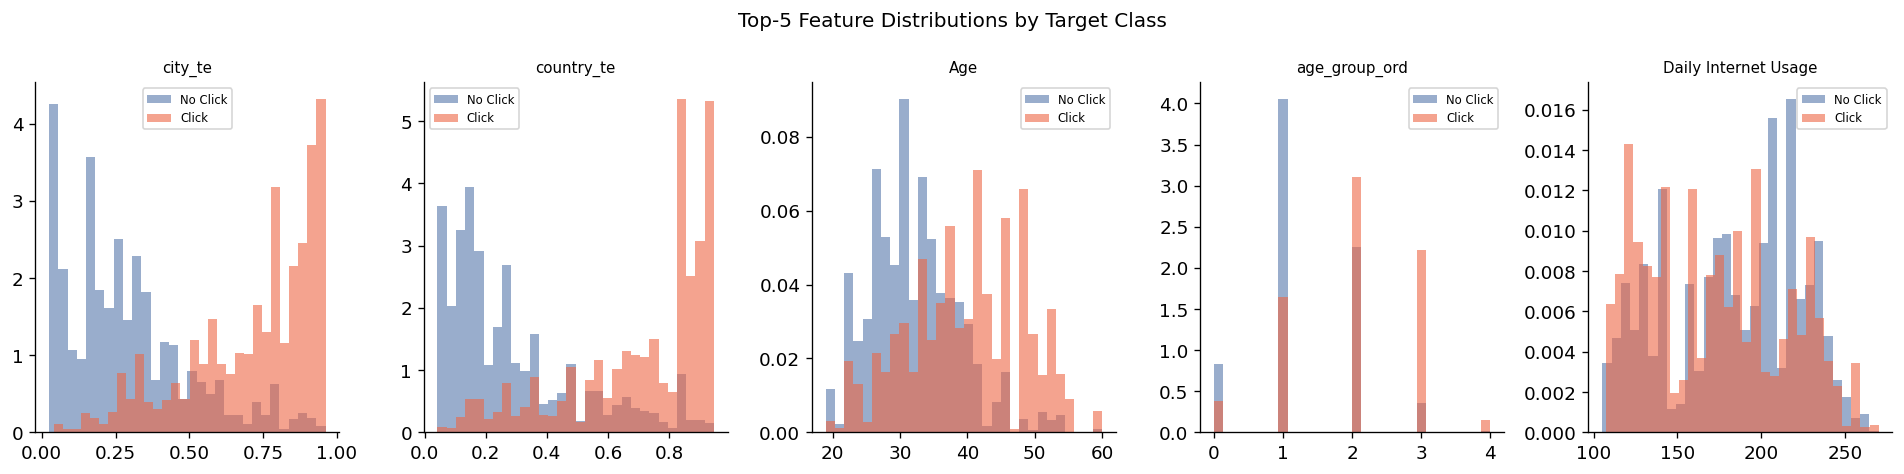

In [17]:
# Distribution overlays — top-5 features by correlation
top5 = corr_series.head(5).index.tolist()
fig_dist, axes = plt.subplots(1, len(top5), figsize=(16, 4))
for ax, col in zip(axes, top5):
    for val, label, color in [(0, "No Click", "#5577AA"), (1, "Click", "#EE6644")]:
        sub = sample_pdf[sample_pdf[LABEL_COL] == val][col].dropna()
        ax.hist(sub, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.legend(fontsize=7)
fig_dist.suptitle("Top-5 Feature Distributions by Target Class", fontsize=12)
plt.tight_layout()
plt.show()

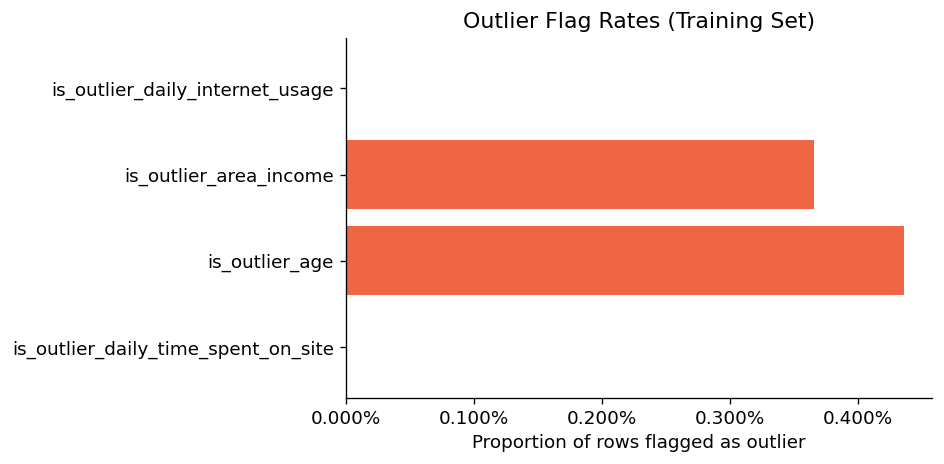

In [18]:
# Outlier flag rates (proportion of training rows flagged)
# Cast to double explicitly — guards against boolean columns if module cache is stale
outlier_rates = (
    df_train
    .select([F.col(c).cast("double").alias(c) for c in outlier_flag_cols])
    .agg(*[F.mean(c).alias(c) for c in outlier_flag_cols])
    .toPandas().T
)
outlier_rates.columns = ["outlier_rate"]

fig_outlier, ax = plt.subplots(figsize=(8, 4))
ax.barh(outlier_rates.index, outlier_rates["outlier_rate"], color="#EE6644")
ax.set_xlabel("Proportion of rows flagged as outlier")
ax.set_title("Outlier Flag Rates (Training Set)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

## 9 · Save Engineered Dataset
Persist train/val/test splits as Delta tables and save transformer artifacts for inference reuse.

In [19]:
# Write Delta splits
for name, sdf in [("train", df_train), ("val", df_val), ("test", df_test)]:
    path = f"{OUTPUT_PATH}/{name}"
    sdf.write.format("delta").mode("overwrite").save(path)
    print(f"Written {name}: {sdf.count():,} rows → {path}")

# Unpersist train now that we're done
df_train.unpersist()

Py4JJavaError: An error occurred while calling o2490.save.
: org.apache.spark.SparkClassNotFoundException: [DATA_SOURCE_NOT_FOUND] Failed to find the data source: delta. Make sure the provider name is correct and the package is properly registered and compatible with your Spark version. SQLSTATE: 42K02
	at org.apache.spark.sql.errors.QueryExecutionErrors$.dataSourceNotFoundError(QueryExecutionErrors.scala:764)
	at org.apache.spark.sql.execution.datasources.DataSource$.lookupDataSource(DataSource.scala:686)
	at org.apache.spark.sql.execution.datasources.DataSource$.lookupDataSourceV2(DataSource.scala:745)
	at org.apache.spark.sql.classic.DataFrameWriter.lookupV2Provider(DataFrameWriter.scala:596)
	at org.apache.spark.sql.classic.DataFrameWriter.saveCommand(DataFrameWriter.scala:141)
	at org.apache.spark.sql.classic.DataFrameWriter.save(DataFrameWriter.scala:115)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)
	at java.base/jdk.internal.reflect.NativeMe

In [ ]:
# Save transformer artifacts
artifacts_path = f"{OUTPUT_PATH}/artifacts"
gender_model.write().overwrite().save(f"{artifacts_path}/gender_pipeline")
tfidf_model .write().overwrite().save(f"{artifacts_path}/tfidf_pipeline")
scale_model .write().overwrite().save(f"{artifacts_path}/scale_pipeline")

# Save encoding maps as JSON
with open(f"{artifacts_path}/country_te_map.json", "w") as f:
    json.dump(country_map, f, indent=2)
with open(f"{artifacts_path}/city_te_map.json", "w") as f:
    json.dump(city_map, f, indent=2)
with open(f"{artifacts_path}/outlier_bounds.json", "w") as f:
    json.dump(outlier_bounds_map, f, indent=2)

print("Artifacts saved to", artifacts_path)

In [ ]:
# Final schema and feature list
df_train_reload = spark.read.format("delta").load(f"{OUTPUT_PATH}/train")
df_train_reload.printSchema()

feature_list = pd.DataFrame({
    "feature": scalar_feature_cols,
    "abs_corr": [corr_series.get(c, None) for c in scalar_feature_cols],
}).sort_values("abs_corr", ascending=False)
feature_list.to_csv(f"{artifacts_path}/feature_list.csv", index=False)
print(feature_list.to_string(index=False))

## 10 · MLflow Logging & Feature Registry
Log all parameters, metrics, encoding maps, and charts to a single MLflow run for full reproducibility.

In [ ]:
train_n = spark.read.format("delta").load(f"{OUTPUT_PATH}/train").count()
val_n   = spark.read.format("delta").load(f"{OUTPUT_PATH}/val")  .count()
test_n  = spark.read.format("delta").load(f"{OUTPUT_PATH}/test") .count()

with mlflow.start_run(run_name="ad_click_feature_engineering"):

    # Params
    mlflow.log_params({
        "input_path":        INPUT_PATH,
        "output_path":       OUTPUT_PATH,
        "random_seed":       RANDOM_SEED,
        "te_alpha":          TE_ALPHA,
        "tfidf_num_features": TFIDF_NUM_FEATURES,
        "tfidf_top_k":       TFIDF_TOP_K,
        "split_ratios":      str(SPLIT_RATIOS),
        "n_scalar_features": n_scalar,
        "n_tfidf_features":  n_tfidf,
        "total_features":    n_scalar + n_tfidf,
        "nzv_threshold":     NZV_THRESHOLD,
    })

    # Metrics
    mlflow.log_metrics({
        "train_rows":          float(train_n),
        "val_rows":            float(val_n),
        "test_rows":           float(test_n),
        "nzv_feature_count":   float(len(nzv_feats)),
    })
    for _, row in balance.iterrows():
        mlflow.log_metric(f"{row['split']}_click_rate", row["click_rate"])

    # Feature schema tag
    mlflow.set_tag("feature_schema", json.dumps(scalar_feature_cols))

    # Artifacts
    mlflow.log_artifact(f"{artifacts_path}/country_te_map.json",  "encoding_maps")
    mlflow.log_artifact(f"{artifacts_path}/city_te_map.json",     "encoding_maps")
    mlflow.log_artifact(f"{artifacts_path}/outlier_bounds.json",  "encoding_maps")
    mlflow.log_artifact(f"{artifacts_path}/feature_list.csv",     "feature_metadata")

    # Charts
    log_figures_to_mlflow({
        "feature_importance":          fig_importance,
        "top5_feature_distributions":  fig_dist,
        "outlier_flag_rates":          fig_outlier,
    })

    run_id = mlflow.active_run().info.run_id
    print(f"MLflow run logged: {run_id}")